# O que é o **KMeans**?
O **KMeans** é um **algoritmo** que divide dados em **K grupos de elementos parecidos**. Ele começa escolhendo **centros** aleatórios, depois associa cada ponto ao centro mais próximo, recalcula esses centros como a média dos pontos do grupo e repete esse processo até estabilizar. No final, cada ponto recebe um cluster, agrupando aqueles com características semelhantes.

# KMeans na rede de karatê do Zachary



In [15]:
from sklearn import cluster
from sklearn.cluster import KMeans
import networkx as nx
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib import colors
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics.cluster import normalized_mutual_info_score
from sklearn.metrics.cluster import adjusted_rand_score
from scipy.io import mmread
import networkx as nx

In [16]:
G = nx.karate_club_graph()

pos = nx.spring_layout(G)

def draw_communities(G, membership, pos, ax, title=""):
    """
    Draws the nodes to a plot with assigned colors for each individual cluster
    Parameters
    ----------
    G : networkx graph
    membership : list
        A list where the position is the student and the value at the position is the student club membership.
        E.g. `print(membership[8]) --> 1` means that student #8 is a member of club 1.
    pos : positioning as a networkx spring layout
        E.g. nx.spring_layout(G)
    ax : matplotlib axes object
        The axes to draw on.
    title : str, optional
        Title for the plot.
    """
    # Convert membership list to a dict where key=club, value=list of students in club
    club_dict = defaultdict(list)
    for student, club in enumerate(membership): # enumerate = índice + valor ao mesmo tempo
        club_dict[club].append(student)

    # Converte números de cluster (0,1,2) em algo que o sistema de cores entende (de 0 até 1 - 0.45, 0.66)
    norm = colors.Normalize(vmin=0, vmax=len(club_dict.keys()))

    for club, members in club_dict.items():
        nx.draw_networkx_nodes(G, pos,
                               nodelist=members,
                               node_color=cm.jet(norm(club)),
                               node_size=500,
                               alpha=0.8,
                               ax=ax)

    # Draw edges (social connections) and show final plot
    if title:
        ax.set_title(title)
    nx.draw_networkx_edges(G, pos, alpha=0.5, ax=ax)

# True labels of the group each student (node) unded up in. Found via the original paper
y_true = [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

#code from: https://www.learndatasci.com/tutorials/k-means-clustering-algorithms-python-intro/

In [17]:
def graph_to_edge_matrix(G):
    """Convert a networkx graph into an edge matrix.
    See https://www.wikiwand.com/en/Incidence_matrix for a good explanation on edge matrices

    Parameters
    ----------
    G : networkx graph
    """
    # Initialize edge matrix with zeros
    edge_mat = np.zeros((len(G), len(G)), dtype=int)

    # Loop to set 0 or 1 (diagonal elements are set to 1)
    for node in G:
        for neighbor in G.neighbors(node):
            edge_mat[node][neighbor] = 1
        edge_mat[node][node] = 1

    return edge_mat

edge_mat = graph_to_edge_matrix(G)
edge_mat

#code from: https://www.learndatasci.com/tutorials/k-means-clustering-algorithms-python-intro/

array([[1, 1, 1, ..., 1, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 1, 0],
       ...,
       [1, 0, 0, ..., 1, 1, 1],
       [0, 0, 1, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1]])

/usr/local/lib/python3.12/dist-packages/networkx/drawing/nx_pylab.py:1497: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


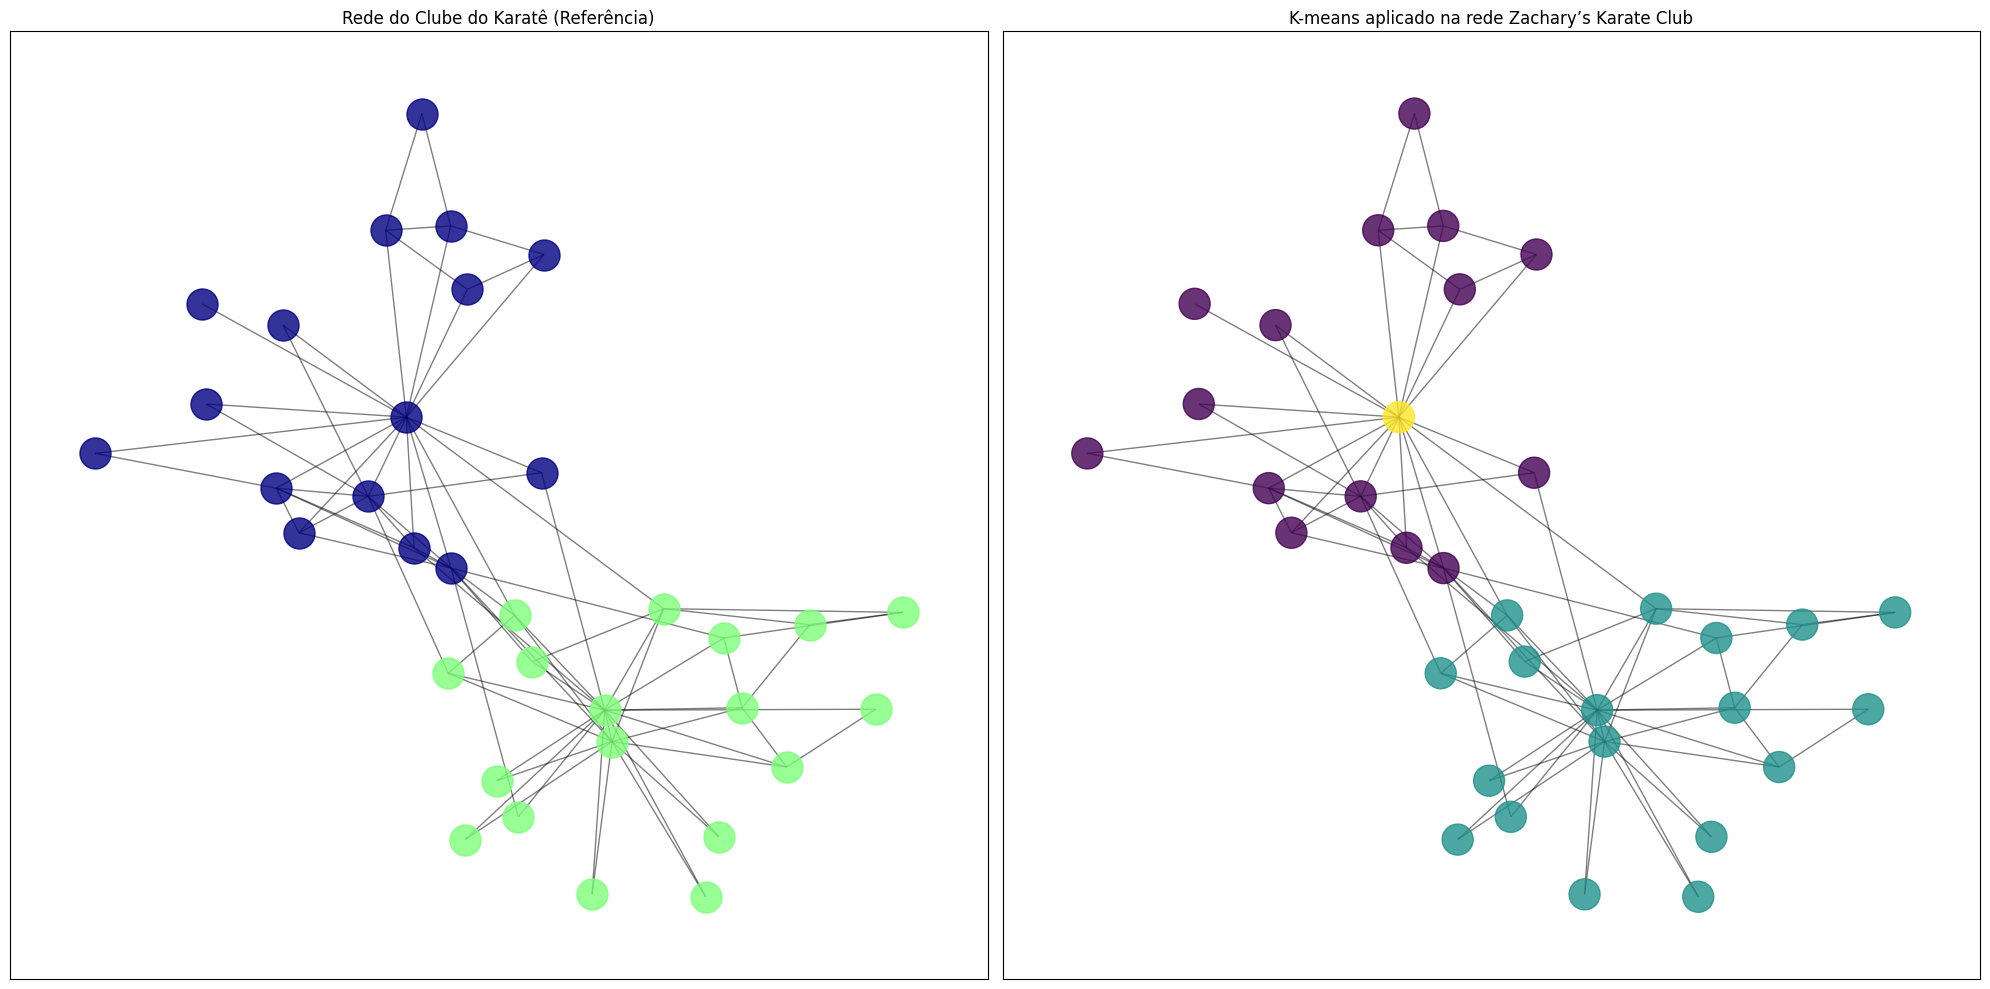

In [39]:
G = nx.karate_club_graph()
edge_mat = graph_to_edge_matrix(G)

kmeans = KMeans(n_clusters=3, random_state=42)

# fit_predict: fit - o kmeans aprende, escolhe os centros e organiza os dados. predict - o kmeans classifica, "prevê" os clusters
labels = kmeans.fit_predict(edge_mat)

# Usar o mesmo layout para ambos os plots para melhor comparação
pos = nx.spring_layout(G, seed=42)

fig, axes = plt.subplots(1, 2, figsize=(20, 10)) # Criar uma figura com dois subplots

# Plot 1: Referência (Ground Truth)
draw_communities(G, y_true, pos, axes[0], title="Rede do Clube do Karatê (Referência)")

# Plot 2: Agrupamento K-Means
nx.draw_networkx_nodes(
    G, pos,
    node_color=labels,
    cmap=plt.cm.viridis, # Usar o mesmo mapa de cores que o plot original do K-Means
    node_size=500, # Aumentar o tamanho do nó para consistência com o plot do Ground Truth
    alpha=0.8,
    ax=axes[1]
)

nx.draw_networkx_edges(G, pos, alpha=0.5, ax=axes[1])
axes[1].set_title("K-means aplicado na rede Zachary’s Karate Club")

plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()

In [19]:
nmi = normalized_mutual_info_score(y_true, labels)
ars = adjusted_rand_score(y_true, labels)

avg = (nmi + ars) / 2

print(f"NMI Score: {nmi*100:.2f}%")
print(f"ARS Score: {ars*100:.2f}%")
print(f"Average Score: {avg*100:.2f}%")

NMI Score: 100.00%
ARS Score: 100.00%
Average Score: 100.00%


# Kmeans aplicado em outros grafos


In [20]:
G = nx.Graph()

letras = "abcdefghijklmnopqrst"

for i in range(len(letras)):
  G.add_node(letras[i])

edges = [
    ('a', 'b'), ('a', 'd'), ('a', 'f'),
    ('b', 'd'), ('b', 'e'),('b','g'),
    ('c', 'f'),('c','h',),('c','r'),
    ('d', 'e'), ('d', 'f'), ('d', 'g'),
    ('e', 'g'),
    ('f', 'g'),
    ('g', 'h'),
    ('h', 'i'), ('h', 'r'),
    ('i', 'j'),('i','p'),('i','n'),
    ('j', 'k'), ('j', 'n'), ('j', 'p'),('j','o'),('j','m'),('j','l'),
    ('k', 'l'),('k','p'),
    ('l', 'm'),
    ('m', 'q'),('m','s'),
    ('n','o'),
    ('q', 's'),
    ('t','s'),('t','m')
]

G.add_edges_from(edges)

# Convert node labels to integers before creating the edge matrix
G_relabel = nx.convert_node_labels_to_integers(G)

edge_mat = graph_to_edge_matrix(G_relabel)
edge_mat

array([[1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
       [1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0,

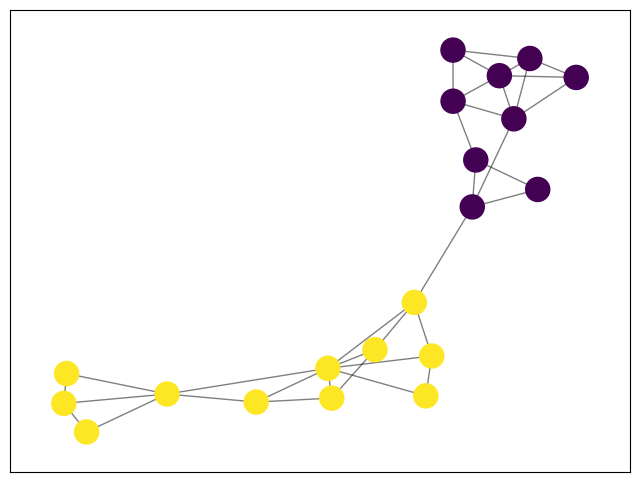

In [21]:
kmeans = KMeans(n_clusters=2, random_state=42)

labels = kmeans.fit_predict(edge_mat)

# Visualizar a rede com cores por cluster
plt.figure(figsize=(8,6))

pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(
    G, pos,
    node_color=labels,
    cmap=plt.cm.viridis,
    node_size=300
)

nx.draw_networkx_edges(G, pos, alpha=0.5)

plt.show()

In [22]:
# Criar grafo vazio
G = nx.Graph()

# Adicionar cluster A (5 nós totalmente conectados)
cluster_A = ['A1', 'A2', 'A3', 'A4', 'A5']
G.add_edges_from([(u, v) for idx, u in enumerate(cluster_A) for v in cluster_A[idx + 1:]])

# Adicionar cluster B (3 nós totalmente conectados)
cluster_B = ['B1', 'B2', 'B3']
G.add_edges_from([(u, v) for idx, u in enumerate(cluster_B) for v in cluster_B[idx + 1:]])

# Adicionar cluster C (linear, 4 nóc)
cluster_C = ['C1', 'C2', 'C3', 'C4']
G.add_edges_from([(cluster_C[i], cluster_C[i+1]) for i in range(len(cluster_C)-1)])

# Adicionar hub central
G.add_node('H')

# Conectar hub aos clusters
G.add_edges_from([('H', 'A1'), ('H', 'B1'), ('H', 'C1')])

# Convert node labels to integers before creating the edge matrix
G_relabel = nx.convert_node_labels_to_integers(G)

edge_mat = graph_to_edge_matrix(G_relabel)
edge_mat

array([[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1],
       [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0],
       [1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1]])

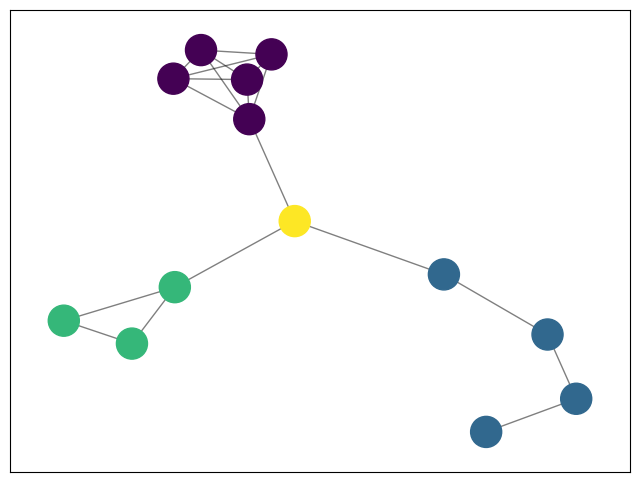

In [23]:
kmeans = KMeans(n_clusters=4, random_state=42)

labels = kmeans.fit_predict(edge_mat)

# Visualizar a rede com cores por cluster
plt.figure(figsize=(8,6))

pos = nx.spring_layout(G, k=0.4, seed=42)

nx.draw_networkx_nodes(
    G, pos,
    node_color=labels,
    cmap=plt.cm.viridis,
    node_size=500
)

nx.draw_networkx_edges(G, pos, alpha=0.5)

plt.show()

In [24]:
G = nx.watts_strogatz_graph(50, 4, 0.2)

pos = nx.spring_layout(G, k=0.5,seed=44)

# Convert node labels to integers before creating the edge matrix
G_relabel = nx.convert_node_labels_to_integers(G)

edge_mat = graph_to_edge_matrix(G_relabel)

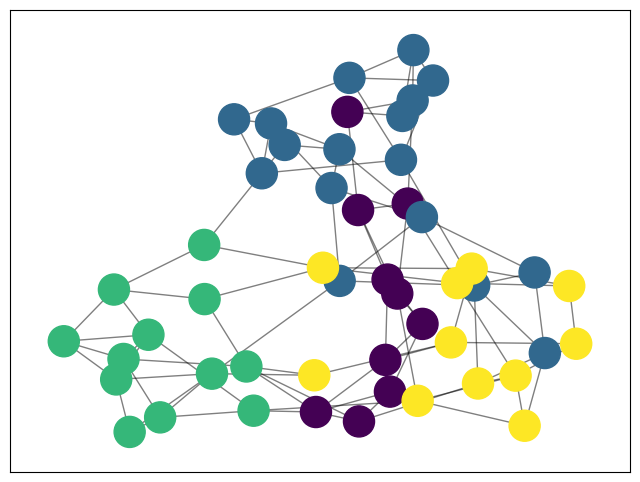

In [25]:
kmeans = KMeans(n_clusters=4, random_state=42)

labels = kmeans.fit_predict(edge_mat)

# Visualizar a rede com cores por cluster
plt.figure(figsize=(8,6))

pos = nx.spring_layout(G, k=0.4, seed=42)

nx.draw_networkx_nodes(
    G, pos,
    node_color=labels,
    cmap=plt.cm.viridis,
    node_size=500
)

nx.draw_networkx_edges(G, pos, alpha=0.5)

plt.show()

In [26]:
G = nx.planted_partition_graph(l=3, k=10, p_in=0.8, p_out=0.05)

pos = nx.spring_layout(G, k=0.3,seed=44)

# Convert node labels to integers before creating the edge matrix
G_relabel = nx.convert_node_labels_to_integers(G)

edge_mat = graph_to_edge_matrix(G_relabel)

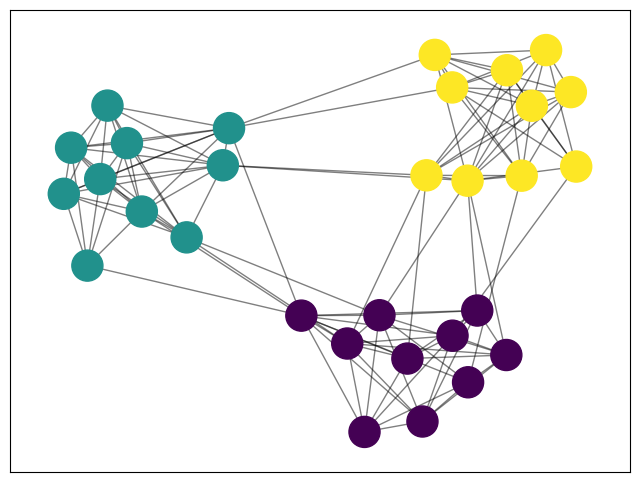

In [27]:
kmeans = KMeans(n_clusters=3, random_state=42)

labels = kmeans.fit_predict(edge_mat)

# Visualizar a rede com cores por cluster
plt.figure(figsize=(8,6))

pos = nx.spring_layout(G, k=0.4, seed=42)

nx.draw_networkx_nodes(
    G, pos,
    node_color=labels,
    cmap=plt.cm.viridis,
    node_size=500
)

nx.draw_networkx_edges(G, pos, alpha=0.5)

plt.show()

# Kmeans aplicado na rede Dolphins Social Network

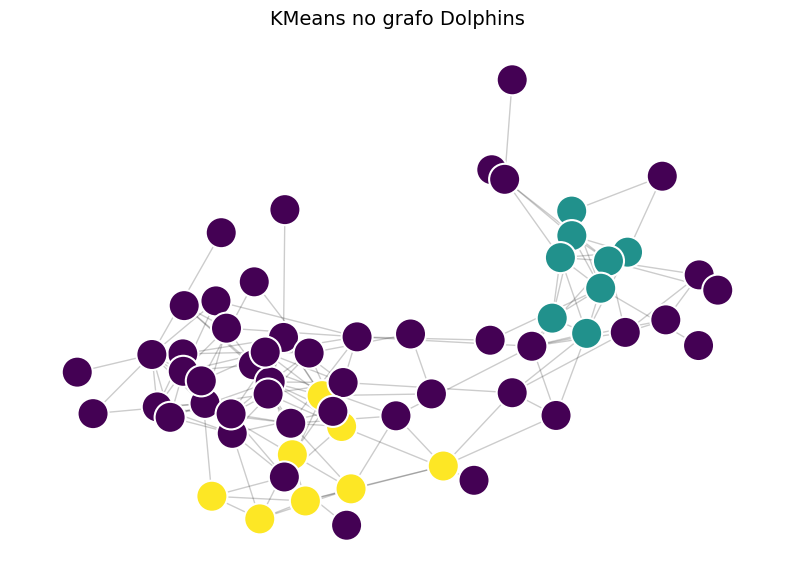

In [28]:
# ler arquivo
edge_mat = mmread("/content/soc-dolphins.mtx")

# converter pra grafo
G = nx.from_scipy_sparse_array(edge_mat)

# K-Means
kmeans = KMeans(n_clusters=3, random_state=42)

# edge_mat é uma matriz esparsa (sparse) do mmread, o K-Means do sklearn não trabalha bem com isso direto, é preciso converter pra array
labels = kmeans.fit_predict(edge_mat.toarray())

pos = nx.spring_layout(G, k=0.4, seed=42)

plt.figure(figsize=(10, 7))

# nós (com borda branca)
nx.draw_networkx_nodes(
    G, pos,
    node_color=labels,
    cmap=plt.cm.viridis,
    node_size=500,
    edgecolors="white",
    linewidths=1.5
)

# arestas mais suaves
nx.draw_networkx_edges(
    G, pos,
    alpha=0.2,
    width=1
)

# título
plt.title("KMeans no grafo Dolphins", fontsize=14)

# remover eixo
plt.axis('off')

plt.show()

# Kmeans no Email-EU-Core Network

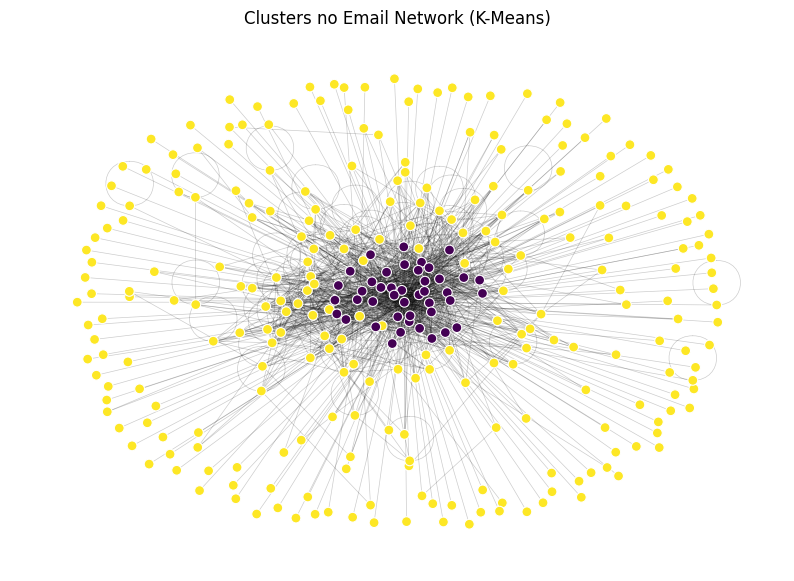

In [29]:
G = nx.read_edgelist("/content/Email-EuAll.txt")

G_small = G.subgraph(list(G.nodes())[:300])

X = nx.to_numpy_array(G_small)

kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X)

import matplotlib.pyplot as plt

pos = nx.spring_layout(G_small, k=0.5, seed=42)

plt.figure(figsize=(10,7))

nx.draw_networkx_nodes(
    G_small, pos,
    node_color=labels,
    cmap=plt.cm.viridis,
    node_size=50,
    edgecolors="white",
    linewidths=0.8
)

nx.draw_networkx_edges(
    G_small, pos,
    alpha=0.2,
    width=0.5
)

plt.title("Clusters no Email Network (K-Means)")
plt.axis('off')

plt.show()